# Seasonality 
* Salinity
* Currents
* Temperature
* Winds (?)

In [1]:
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.colors import BoundaryNorm

# month labels, shared by every 12-panel monthly plot below
labs = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
        'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

In [2]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Salinity and Currents 0-7m

In [3]:
sal = xr.open_dataset('Sal_m_0_7m.zarr').compute()
sal

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 499, lon: 1260, time: 264)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
Data variables:
    sal      (time, lat, lon) float64 1GB 35.74 35.74 35.74 ... nan nan nan

In [4]:
mesh = xr.open_dataset("/work/bk1450/b383184/Amazon/Mercator/data/Hgr_cmesh.nc").isel(t=0).compute()
mesh

<xarray.Dataset> Size: 70MB
Dimensions:       (y: 499, x: 1260, z: 50)
Dimensions without coordinates: y, x, z
Data variables: (12/21)
    nav_lon       (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    nav_lat       (y, x) float32 3MB -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
    nav_lev       (z) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    time_counter  float64 8B 0.0
    glamt         (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    glamu         (y, x) float32 3MB -94.96 -94.88 -94.79 ... 9.805 9.889 9.972
    ...            ...
    e1f           (y, x) float64 5MB 9.128e+03 9.128e+03 ... 8.028e+03 8.028e+03
    e2t           (y, x) float64 5MB 9.127e+03 9.127e+03 ... 7.847e+03 7.845e+03
    e2u           (y, x) float64 5MB 9.127e+03 9.127e+03 ... 7.846e+03 7.845e+03
    e2v           (y, x) float64 5MB 9.128e+03 9.128e+03 ... 7.843e+03 7.841e+03
    e2f           (y, x) float64 5MB 9.128e+03 9.128e+03 ... 7.842e+03 7.841e+03
    ff            (y, x) float64 5MB -2.51e-05 -2.51e-05 ... 7.288e-05 7.288e-05
Attributes:
    file_name:            mesh_hgr.nc
    TimeStamp:            03/02/2016 10:24:55 -0000
    Unlimited_Dimension:  t

In [5]:
u =  xr.open_zarr('U_m_0_7m.zarr').compute()
u = u.rename({'time_counter':'time'})
print(u)

v =  xr.open_zarr('V_m_0_7m.zarr').compute()
v = v.rename({'time_counter':'time'})
print(v)

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 264, y: 499, x: 1260)
Coordinates:
    nav_lat  (y, x) float32 3MB -9.95 -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
    nav_lon  (y, x) float32 3MB -94.96 -94.88 -94.79 ... 9.805 9.889 9.972
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * x        (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y        (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
Data variables:
    U        (time, y, x) float64 1GB -0.1345 -0.1377 -0.1375 ... nan nan nan
<xarray.Dataset> Size: 1GB
Dimensions:  (time: 264, y: 499, x: 1260)
Coordinates:
    nav_lat  (y, x) float32 3MB -9.909 -9.909 -9.909 ... 29.98 29.98 29.98
    nav_lon  (y, x) float32 3MB -95.0 -94.92 -94.83 -94.75 ... 9.764 9.847 9.93
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * x        (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y        (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+0

In [6]:
U_ = seasonality((u.U.shift(x=1) + u.U)*0.5)
V_ = seasonality((v.V.shift(y=1) + v.V)*0.5)

In [13]:
# ── Precompute everything that doesn't change ───────────
lon_T = mesh["glamt"].values
lat_T = mesh["gphit"].values

s = 10
lon_s = lon_T[::s, ::s]
lat_s = lat_T[::s, ::s]

extent = [-80, -10, -5, 20]
proj = ccrs.PlateCarree()

# Pre-stack all months into a single array for vectorized access
# Assumes U_, V_ have a 'month' dim 1..12
U_all = U_.values   # shape (12, y, x) — one load, no .sel() overhead per iter
V_all = V_.values

# --- per-variable plotting config: colormap, colorbar label, discrete levels ---
# add a new variable by adding one entry to each of the three dicts.
cmaps = {
    "sal": "jet",
}
labels = {
    "sal": "depth weighted salinity 0-7 m",
}
LEVELS = {
    "sal": np.arange(30, 36, 0.5),
}

# contourf draws at zorder 1, so land/coastlines must sit above it or the filled
# contours bury the continents.
Z_DATA, Z_LAND, Z_COAST = 1, 3, 4


def plot_monthly(da, name, quiver=False, box=True, save=True):
    """12-panel monthly map of `da` (dim `month`, 1..12). Colormap, colorbar label
    and discrete contour levels are looked up from the cmaps/labels/LEVELS dicts by
    `name`. Optionally overlays the 0-7 m current vectors and the ARP box."""
    cmap, label, levels = cmaps[name], labels[name], LEVELS[name]
    cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True) if levels is not None else None

    fig, ax = plt.subplots(4, 3, figsize=(12, 8), subplot_kw=dict(projection=proj))
    ax = ax.ravel()

    for i in range(12):
        dd = da.sel(month=i + 1)

        pcm = dd.plot.contourf(
            x="lon", y="lat", ax=ax[i], transform=proj,
            cmap=cmap, levels=levels, norm=norm, add_colorbar=False,
            zorder=Z_DATA,
        )

        if quiver:
            ax[i].quiver(
                lon_s, lat_s,
                U_all[i, ::s, ::s], V_all[i, ::s, ::s],
                scale=30, width=0.002, headwidth=4,
                transform=proj, color="white", alpha=0.7,
                zorder=Z_DATA + 1,
            )

        if box:
            ax[i].add_patch(mpatches.Rectangle(
                xy=(-65, -2), width=20, height=20,
                linewidth=1.5, edgecolor="red", facecolor="none",
                transform=proj, zorder=Z_COAST + 1,
            ))

        ax[i].add_feature(cf.LAND, facecolor="#8e9497ff", zorder=Z_LAND)
        ax[i].coastlines(zorder=Z_COAST)
        ax[i].set_extent(extent, crs=proj)
        ax[i].set_title(labs[i], fontsize=10)
        ax[i].set_xticks(np.arange(extent[0], extent[1] + 1e-6, 10), crs=proj)
        ax[i].set_yticks(np.arange(extent[2], extent[3] + 1e-6, 5), crs=proj)
        ax[i].xaxis.set_major_formatter(LongitudeFormatter(number_format=".0f", degree_symbol="°"))
        ax[i].yaxis.set_major_formatter(LatitudeFormatter(number_format=".0f", degree_symbol="°"))
        ax[i].tick_params(labelsize=8)
        ax[i].set_xlabel("")
        ax[i].set_ylabel("")

    fig.subplots_adjust(
        left=0.05, right=0.95,
        bottom=0.08, top=0.90,
        wspace=0.05, hspace=0.4
    )
    cbar = fig.colorbar(pcm, ax=ax, orientation="horizontal", fraction=0.05, pad=0.10,
                        ticks=levels)
    cbar.ax.set_xlabel(label, fontsize=10)
    if save:
        plt.savefig(f"figures/seasonality_{name}{'_currents' if quiver else ''}.png",
                    dpi=300, bbox_inches="tight")
    plt.show()

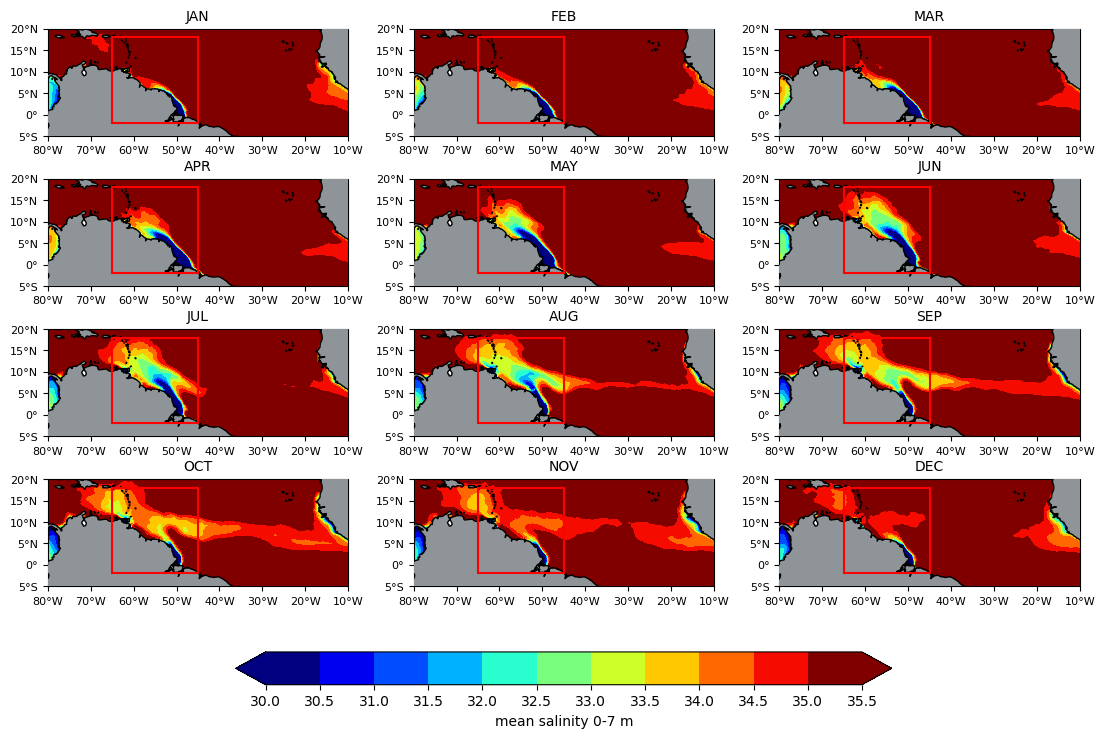

In [11]:
sal_m = seasonality(sal.sel(lat=slice(-5, 20), lon=slice(-80, -10)).sal)

plot_monthly(sal_m, "sal")

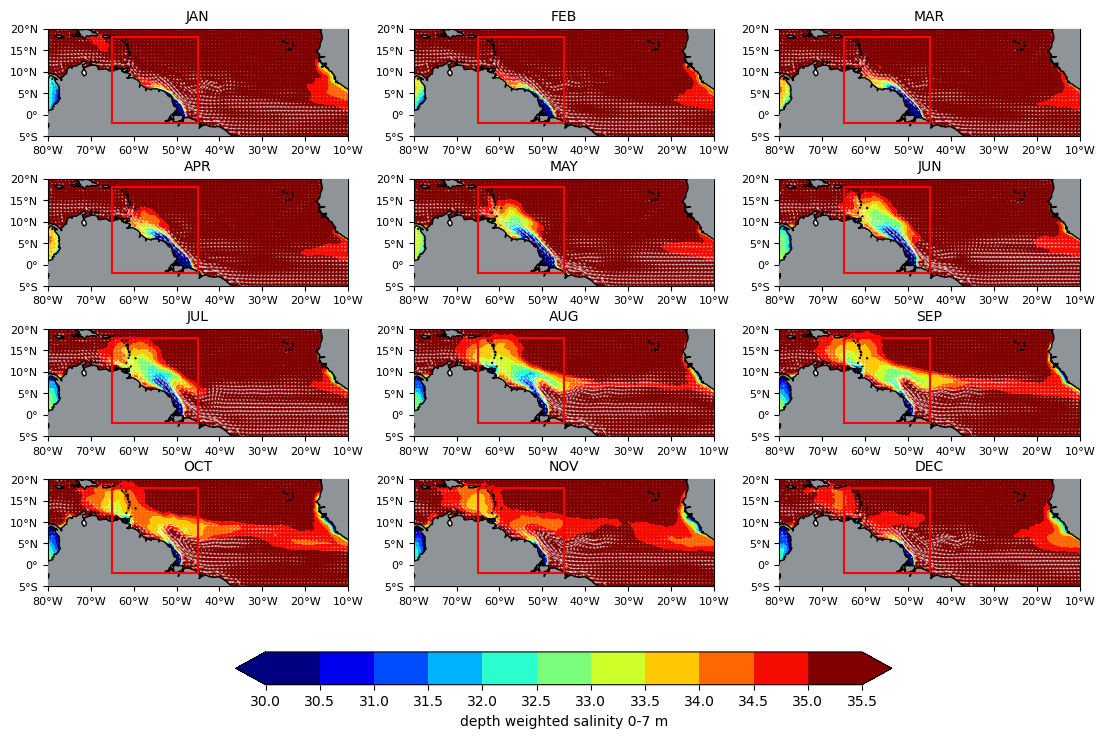

In [14]:
plot_monthly(sal_m, "sal", quiver=True)